In [15]:
import pandas as pd # load data and handle dataframes
import numpy as np # numerical operations
import matplotlib.pyplot as plt # visualization
from sklearn.ensemble import RandomForestRegressor # random forest model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # evaluation metrics
import warnings # ignore warnings for cleaner output
warnings.filterwarnings('ignore')

1. Load the preprocessed csv files

In [16]:
X_train = pd.read_csv('X_train_raw.csv')
X_test = pd.read_csv('X_test_raw.csv')
y_train = pd.read_csv('y_train.csv')['Rings'] + 1.5
y_test = pd.read_csv('y_test.csv')['Rings'] + 1.5
print("Data loading completed")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}\n")

Data loading completed
Training set: (3341, 10)
Test set: (836, 10)



2. Train the Default Random Forest Regressor

In [17]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Default parameter performance of random forest")
print(f"Random Forest MSE: {mse:.4f}")
print(f"Random Forest MAE: {mae:.4f}")
print(f"Random Forest R²: {r2:.4f}\n")


Default parameter performance of random forest
Random Forest MSE: 5.1074
Random Forest MAE: 1.5827
Random Forest R²: 0.5282



3. Hyperparameter Sweeping (Randomized Search)

In [12]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Define the hyperparameter search space
param_dist = {
    'n_estimators': [50, 100, 200, 300],          # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],              # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],              # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],                # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', None]        # Number of features to consider when looking for the best split
}

# 2. Set up the randomized search
rf_base = RandomForestRegressor(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=10, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    random_state=42, 
    n_jobs=-1
)

# 3. Run the hyperparameter tuning and retrieve the best model
rf_random.fit(X_train, y_train)

print("Best Parameters:", rf_random.best_params_)
best_rf = rf_random.best_estimator_  # Optimal model obtained from tuning

# 4. Evaluate the best model's hyperperformance on the test set
y_pred_best = best_rf.predict(X_test)
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"\n==== Hyperperformance Comparison (Before vs. After Tuning) ====")
print(f"Random Forest MSE: {mse_best:.4f} (Default Random Forest: {mse:.4f})")
print(f"Random Forest MAE: {mae_best:.4f} (Default Random Forest: {mae:.4f})")
print(f"Random Forest R²:  {r2_best:.4f}  (Default Random Forest: {r2:.4f})")

Best Parameters: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}

==== Hyperperformance Comparison (Before vs. After Tuning) ====
Random Forest MSE: 4.7970 (Default Random Forest: 5.1074)
Random Forest MAE: 1.5479 (Default Random Forest: 1.5827)
Random Forest R²:  0.5569  (Default Random Forest: 0.5282)


3. Prediction difficulty by age (MAE)

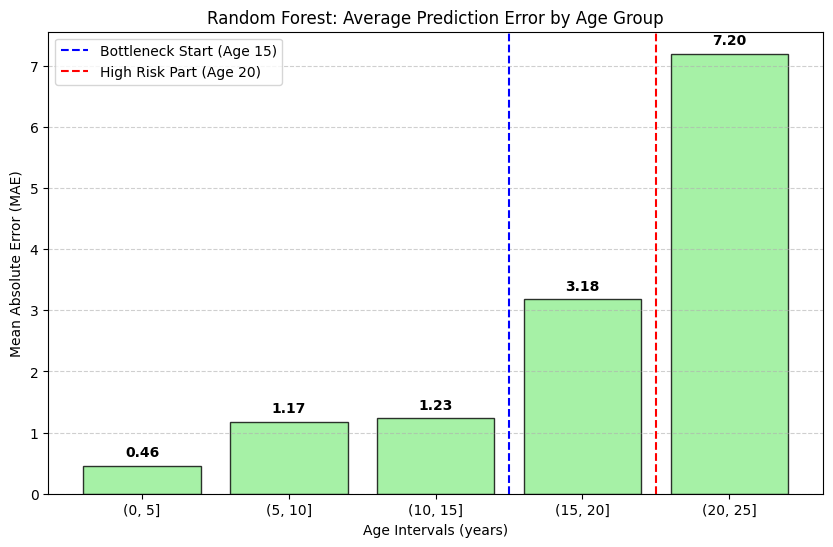

In [13]:
y_pred_tuned = best_rf.predict(X_test)

bin = [0, 5, 10, 15, 20, 25]
labels = ['(0, 5]', '(5, 10]', '(10, 15]', '(15, 20]', '(20, 25]']

results_df = pd.DataFrame({'True_Age': y_test, 'MAE': np.abs(y_test - y_pred_tuned)})
results_df['Age_Group'] = pd.cut(results_df['True_Age'], bins=bin, labels=labels)

group_mae = results_df.groupby('Age_Group', observed=True)['MAE'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(group_mae.index, group_mae.values, color='lightgreen', edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f'{yval:.2f}', ha='center', va='bottom', fontweight='bold')

plt.axvline(x=2.5, color='blue', linestyle='--', label='Bottleneck Start (Age 15)')
plt.axvline(x=3.5, color='red', linestyle='--', label='High Risk Part (Age 20)')

plt.xlabel("Age Intervals (years)")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("Random Forest: Average Prediction Error by Age Group")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig("random_forest_mae_by_age_bins.png", dpi=150)
plt.show()


4. Global vs. Local Modelling

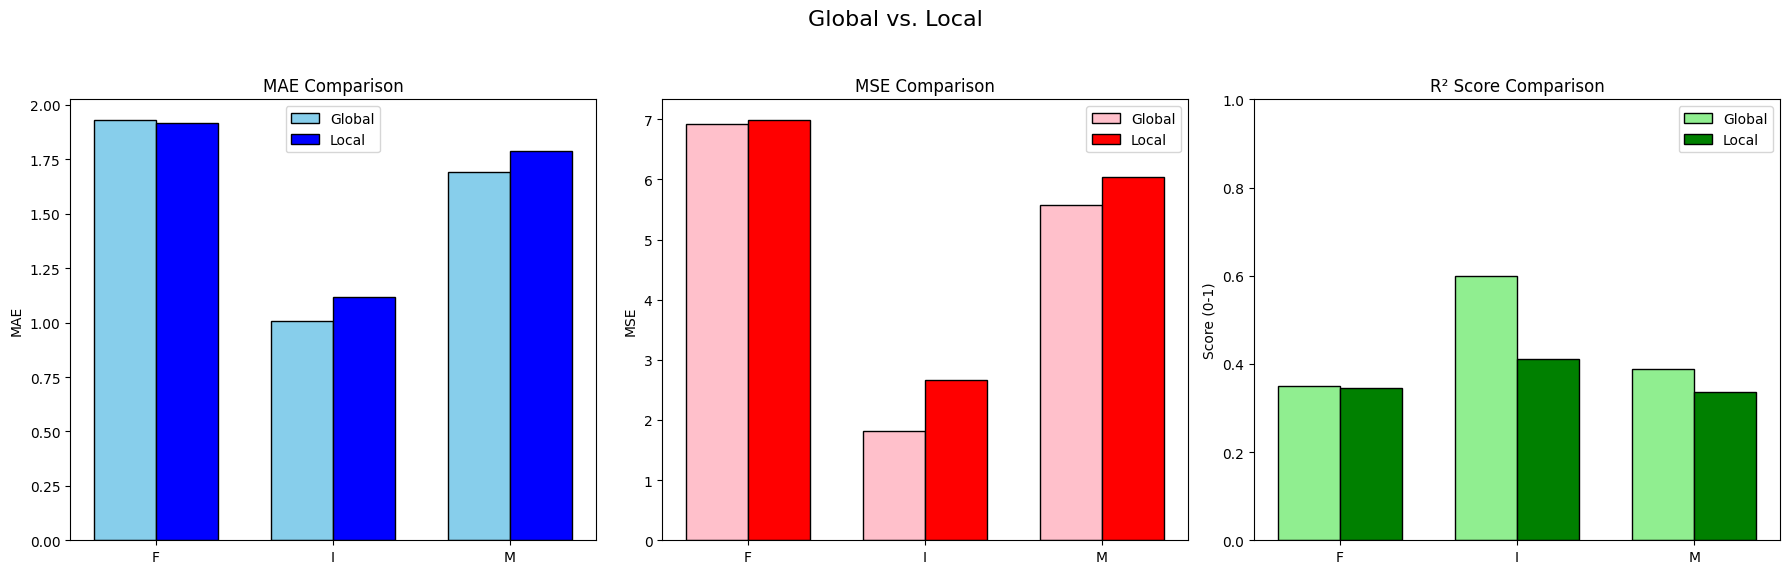

In [14]:
# a. Restore the gender label from one-hot encoding
def get_sex_label(row):
    if row['Sex_I'] == 1: return 'I'
    if row['Sex_F'] == 1: return 'F'
    return 'M'

X_train_sex = X_train.copy() # Create copies to avoid modifying original data
X_test_sex = X_test.copy()
X_train_sex['Sex'] = X_train_sex.apply(get_sex_label, axis=1)
X_test_sex['Sex'] = X_test_sex.apply(get_sex_label, axis=1)

genders = ['F', 'I', 'M']
comparison_results = []

# b: Experimental Loop (Metric Calculation) 
for sex in genders:
    # Extract the test subset for the specific gender
    idx_test = (X_test_sex['Sex'] == sex)
    X_test_sub = X_test[idx_test]
    y_test_sub = y_test[idx_test]
    
    # Global Evaluation
    y_pred_g = best_rf.predict(X_test_sub) # Using the random forest model
    g_mae = mean_absolute_error(y_test_sub, y_pred_g)
    g_mse = mean_squared_error(y_test_sub, y_pred_g)
    g_r2 = r2_score(y_test_sub, y_pred_g)
    
    # Local Evaluation
    # Train a new model using ONLY data from this specific gender
    idx_train = (X_train_sex['Sex'] == sex)
    rf_local = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_local.fit(X_train[idx_train], y_train[idx_train])
    y_pred_l = rf_local.predict(X_test_sub)
    l_mae = mean_absolute_error(y_test_sub, y_pred_l)
    l_mse = mean_squared_error(y_test_sub, y_pred_l)
    l_r2 = r2_score(y_test_sub, y_pred_l)
    
    comparison_results.append({
        'Gender': sex,
        'G_MAE': g_mae, 'L_MAE': l_mae,
        'G_MSE': g_mse, 'L_MSE': l_mse,
        'G_R2': g_r2, 'L_R2': l_r2
    })

comp_df = pd.DataFrame(comparison_results)

# c. Visualization of Global vs. Local Performance across Metrics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
x = np.arange(len(genders))
width = 0.35

# MAE Comparison
ax1.bar(x - width/2, comp_df['G_MAE'], width, label='Global', color='skyblue', edgecolor='black')
ax1.bar(x + width/2, comp_df['L_MAE'], width, label='Local', color='blue', edgecolor='black')
ax1.set_title('MAE Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(genders)
ax1.set_ylabel('MAE')
ax1.legend()

# MSE Comparison
ax2.bar(x - width/2, comp_df['G_MSE'], width, label='Global', color='pink', edgecolor='black')
ax2.bar(x + width/2, comp_df['L_MSE'], width, label='Local', color='red', edgecolor='black')
ax2.set_title('MSE Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(genders)
ax2.set_ylabel('MSE')
ax2.legend()

# R2 Score Comparison
ax3.bar(x - width/2, comp_df['G_R2'], width, label='Global', color='lightgreen', edgecolor='black')
ax3.bar(x + width/2, comp_df['L_R2'], width, label='Local', color='green', edgecolor='black')
ax3.set_title('R² Score Comparison')
ax3.set_xticks(x)
ax3.set_xticklabels(genders)
ax3.set_ylabel('Score (0-1)')
ax3.set_ylim(0, 1) # R2 range
ax3.legend()

plt.suptitle('Global vs. Local', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("random_forest_global_local_triple_check.png", dpi=200)
plt.show()